# AI-Powered Retail Demand Forecasting and Inventory Optimization

## Notebook 05 — Model Training and Evaluation

### Objective

The objective of this notebook is to train, evaluate, and compare machine
learning models for retail demand forecasting.

The workflow includes:

1. Load the engineered datasets
2. Prepare numerical and categorical features
3. Establish forecasting baselines
4. Train a regularized linear model
5. Train a Random Forest model
6. Train an XGBoost model
7. Evaluate models using forecasting metrics
8. Compare validation performance
9. Select the best-performing model
10. Perform final evaluation on the unseen test set
11. Save the final model and metadata

### Important

The test set is not used for model selection or hyperparameter tuning.

Model selection is based on validation performance.

In [1]:
import os
import json
import pickle
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Train, Validation and Test Datasets

The datasets were generated in Notebook 04 using chronological splitting.

We will not randomly reshuffle the observations.

In [2]:
TRAIN_PATH = "../data/processed/train.csv"
VALIDATION_PATH = "../data/processed/validation.csv"
TEST_PATH = "../data/processed/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df["Date"] = pd.to_datetime(train_df["Date"])
validation_df["Date"] = pd.to_datetime(validation_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
print("Dataset sizes")
print("=" * 50)

print(f"Training   : {train_df.shape}")
print(f"Validation : {validation_df.shape}")
print(f"Test       : {test_df.shape}")

Dataset sizes
Training   : (51000, 55)
Validation : (11000, 55)
Test       : (11000, 55)


In [4]:
print("Date ranges")
print("=" * 50)

print(
    f"Train      : "
    f"{train_df['Date'].min().date()} → "
    f"{train_df['Date'].max().date()}"
)

print(
    f"Validation : "
    f"{validation_df['Date'].min().date()} → "
    f"{validation_df['Date'].max().date()}"
)

print(
    f"Test       : "
    f"{test_df['Date'].min().date()} → "
    f"{test_df['Date'].max().date()}"
)

Date ranges
Train      : 2022-01-31 → 2023-06-24
Validation : 2023-06-25 → 2023-10-12
Test       : 2023-10-13 → 2024-01-30


In [5]:
assert train_df["Date"].max() < validation_df["Date"].min()
assert validation_df["Date"].max() < test_df["Date"].min()

print("Chronological separation verified.")

Chronological separation verified.


## 2. Define Target Variable

The target variable is:

`Demand`

The model will predict demand for each store-product observation.

In [6]:
TARGET = "Demand"

print(f"Target variable: {TARGET}")

Target variable: Demand


In [7]:
categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

categorical_features

['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Promotion',
 'Seasonality',
 'Epidemic']

In [8]:
# Date is not directly passed to the models.
# It has already been converted into calendar features.

excluded_columns = [
    "Date",
    TARGET
]

feature_columns = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

numerical_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

print(f"Total features      : {len(feature_columns)}")
print(f"Numerical features  : {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Total features      : 53
Numerical features  : 45
Categorical features: 8


In [9]:
X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[TARGET].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].copy()

print("Feature matrices created.")

print(f"X_train      : {X_train.shape}")
print(f"X_validation : {X_validation.shape}")
print(f"X_test       : {X_test.shape}")

Feature matrices created.
X_train      : (51000, 53)
X_validation : (11000, 53)
X_test       : (11000, 53)


In [10]:
target_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Mean Demand": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean()
    ],
    "Std Demand": [
        y_train.std(),
        y_validation.std(),
        y_test.std()
    ],
    "Min Demand": [
        y_train.min(),
        y_validation.min(),
        y_test.min()
    ],
    "Max Demand": [
        y_train.max(),
        y_validation.max(),
        y_test.max()
    ]
})

target_summary

,Dataset,Mean Demand,Std Demand,Min Demand,Max Demand
0,Train,103.114510,47.077084,4,378
1,Validation,112.674182,48.472427,4,430
2,Test,99.848364,44.743543,4,330


## 3. Evaluation Metrics

We use:

### MAE — Mean Absolute Error

Measures the average absolute forecasting error.

Lower is better.

### RMSE — Root Mean Squared Error

Penalizes larger errors more strongly than MAE.

Lower is better.

### sMAPE — Symmetric Mean Absolute Percentage Error

Provides a scale-independent percentage-based error measure.

Lower is better.

### R² — Coefficient of Determination

Measures the proportion of variance explained by the model.

Higher is better.

For model selection, MAE and RMSE will be given particular importance because
they are directly interpretable in demand units.

In [11]:
def smape(y_true, y_pred):
    """
    Calculate Symmetric Mean Absolute Percentage Error.
    """
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    )

    mask = denominator != 0

    return (
        100 *
        np.mean(
            2 *
            np.abs(y_pred[mask] - y_true[mask]) /
            denominator[mask]
        )
    )

In [12]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    """
    Calculate forecasting evaluation metrics.
    """
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    smape_value = smape(
        y_true,
        y_pred
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "R2": r2
    }

## 4. Baseline Model — Mean Demand

The first baseline predicts the average training demand for every validation
observation.

Any useful machine learning model should substantially outperform this
baseline.

In [13]:
mean_prediction = np.full(
    len(y_validation),
    y_train.mean()
)

mean_baseline_result = evaluate_model(
    "Mean Baseline",
    y_validation,
    mean_prediction
)

mean_baseline_result

{'Model': 'Mean Baseline',
 'MAE': 37.51608570409982,
 'RMSE': np.float64(49.40394618656848),
 'sMAPE (%)': np.float64(34.67774355390668),
 'R2': -0.038898776287471515}

## 5. Baseline Model — Previous Demand

The previous observed demand is used as the prediction.

This is a simple persistence/naive forecasting baseline.

It is useful because a forecasting model should ideally outperform a simple
historical-demand strategy.

In [14]:
lag1_baseline = validation_df["Lag_1"].values

valid_mask = ~np.isnan(lag1_baseline)

lag1_result = evaluate_model(
    "Lag-1 Baseline",
    y_validation.values[valid_mask],
    lag1_baseline[valid_mask]
)

lag1_result

{'Model': 'Lag-1 Baseline',
 'MAE': 44.49918181818182,
 'RMSE': np.float64(57.78735077065663),
 'sMAPE (%)': np.float64(40.75190535595539),
 'R2': -0.4213974258542532}

In [15]:
baseline_results = pd.DataFrame([
    mean_baseline_result,
    lag1_result
])

baseline_results

,Model,MAE,RMSE,sMAPE (%),R2
0,Mean Baseline,37.516086,49.403946,34.677744,-0.038899
1,Lag-1 Baseline,44.499182,57.787351,40.751905,-0.421397


## 6. Feature Preprocessing

Categorical variables are converted into numerical representations using
one-hot encoding.

Numerical variables are passed through appropriate preprocessing.

The preprocessing is fitted only on the training data through the sklearn
pipeline to prevent information leakage.

In [16]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 7. Ridge Regression

Ridge regression provides a strong linear baseline.

It is useful for determining whether the forecasting problem can be explained
reasonably well through a mostly linear relationship between the engineered
features and demand.

In [17]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=10.0)
        )
    ]
)

print("Ridge model created.")

Ridge model created.


In [18]:
ridge_pipeline.fit(
    X_train,
    y_train
)

print("Ridge model trained.")

Ridge model trained.


In [19]:
ridge_validation_pred = ridge_pipeline.predict(
    X_validation
)

ridge_result = evaluate_model(
    "Ridge Regression",
    y_validation,
    ridge_validation_pred
)

ridge_result

{'Model': 'Ridge Regression',
 'MAE': 18.262270645685106,
 'RMSE': np.float64(23.703175738984903),
 'sMAPE (%)': np.float64(17.92368442027025),
 'R2': 0.7608540515036003}

## 8. Random Forest Regressor

Random Forest is a non-linear ensemble model.

It can capture:

- Non-linear relationships
- Feature interactions
- Complex demand patterns

It will be compared against the linear model and baselines.

In [20]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=20,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [22]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained.")

Random Forest model trained.


In [26]:
rf_validation_pred = (
    random_forest_pipeline.predict(
        X_validation
    )
)

rf_result = evaluate_model(
    "Random Forest",
    y_validation,
    rf_validation_pred
)

rf_result

{'Model': 'Random Forest',
 'MAE': 17.6876049679963,
 'RMSE': np.float64(22.93671338259087),
 'sMAPE (%)': np.float64(17.170853806392962),
 'R2': 0.7760699742299715}

## 9. XGBoost Regressor

XGBoost is a gradient-boosted decision-tree algorithm.

It is particularly suitable for structured/tabular datasets and can model
non-linear relationships and feature interactions.

The initial configuration is intentionally conservative. Hyperparameter
tuning will be performed only after comparing the initial models.

In [27]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                max_depth=8,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost model created.")

XGBoost model created.


In [29]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost model trained.")

XGBoost model trained.


In [30]:
xgb_validation_pred = (
    xgb_pipeline.predict(
        X_validation
    )
)

xgb_result = evaluate_model(
    "XGBoost",
    y_validation,
    xgb_validation_pred
)

xgb_result

{'Model': 'XGBoost',
 'MAE': 12.521531105041504,
 'RMSE': np.float64(16.69673455572133),
 'sMAPE (%)': np.float64(12.215538916546652),
 'R2': 0.8813376426696777}

## 10. Validation Model Comparison

All candidate models are now evaluated on the same validation period.

The test set has not been used for model selection.

In [31]:
validation_results = pd.DataFrame([
    mean_baseline_result,
    lag1_result,
    ridge_result,
    rf_result,
    xgb_result
])

validation_results = validation_results.sort_values(
    "MAE"
).reset_index(drop=True)

validation_results

,Model,MAE,RMSE,sMAPE (%),R2
0,XGBoost,12.521531,16.696735,12.215539,0.881338
1,Random Forest,17.687605,22.936713,17.170854,0.776070
2,Ridge Regression,18.262271,23.703176,17.923684,0.760854
3,Mean Baseline,37.516086,49.403946,34.677744,-0.038899
4,Lag-1 Baseline,44.499182,57.787351,40.751905,-0.421397


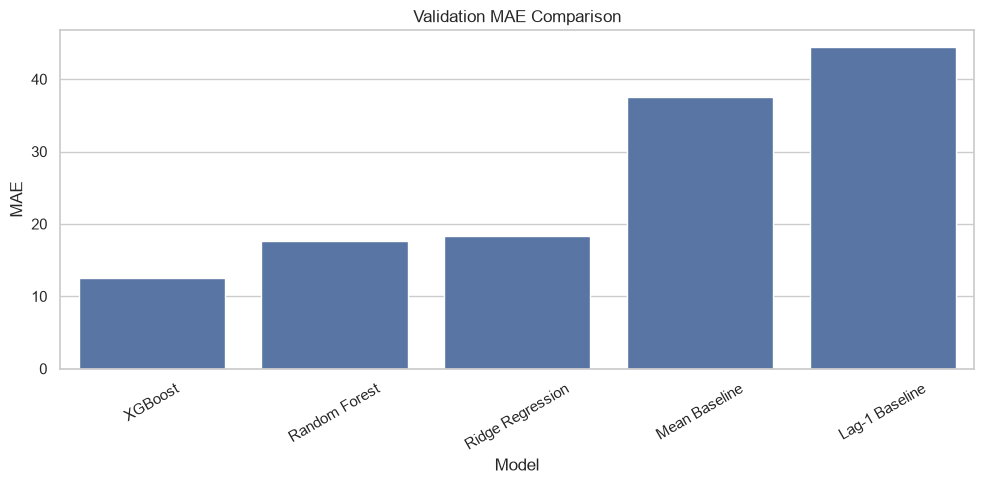

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=validation_results,
    x="Model",
    y="MAE"
)

plt.title("Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

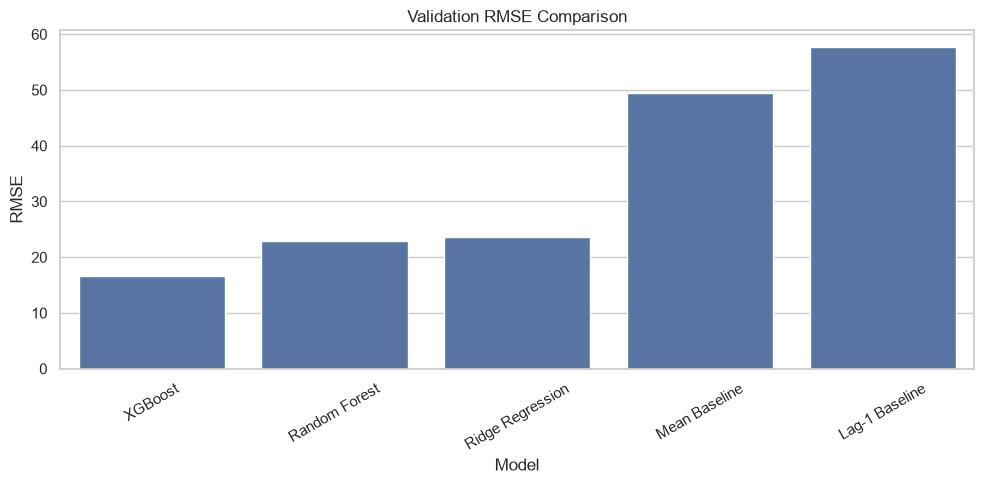

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=validation_results,
    x="Model",
    y="RMSE"
)

plt.title("Validation RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 11. Initial Model Selection

The initial model is selected based primarily on validation MAE.

MAE is directly interpretable in the same units as demand.

RMSE is also considered because it provides greater penalty for large
forecasting errors.

In [34]:
best_model_name = (
    validation_results
    .sort_values("MAE")
    .iloc[0]["Model"]
)

print(
    f"Best validation model based on MAE: "
    f"{best_model_name}"
)

Best validation model based on MAE: XGBoost


## 12. Actual vs Predicted Demand

We visualize the predictions of the strongest initial model against the actual
validation demand.

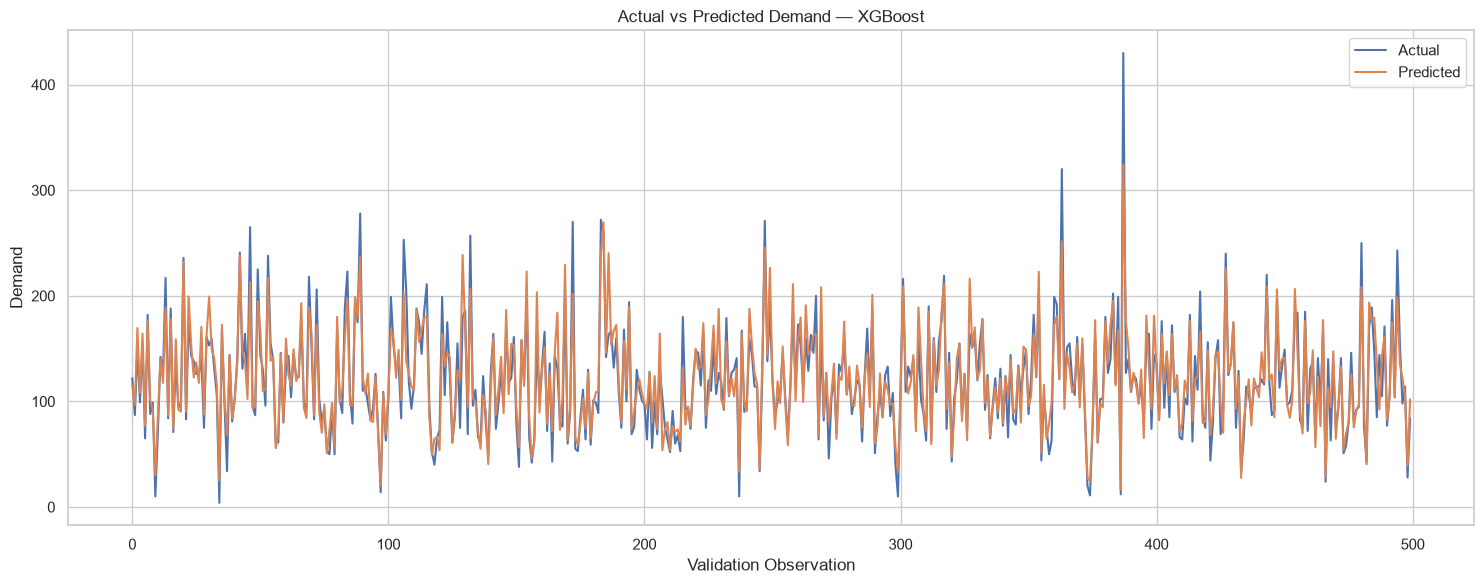

In [35]:
prediction_map = {
    "Ridge Regression": ridge_validation_pred,
    "Random Forest": rf_validation_pred,
    "XGBoost": xgb_validation_pred
}

best_validation_predictions = prediction_map.get(
    best_model_name
)

if best_validation_predictions is not None:

    plt.figure(figsize=(15, 6))

    plt.plot(
        y_validation.values[:500],
        label="Actual"
    )

    plt.plot(
        best_validation_predictions[:500],
        label="Predicted"
    )

    plt.title(
        f"Actual vs Predicted Demand — {best_model_name}"
    )

    plt.xlabel("Validation Observation")
    plt.ylabel("Demand")

    plt.legend()

    plt.tight_layout()
    plt.show()

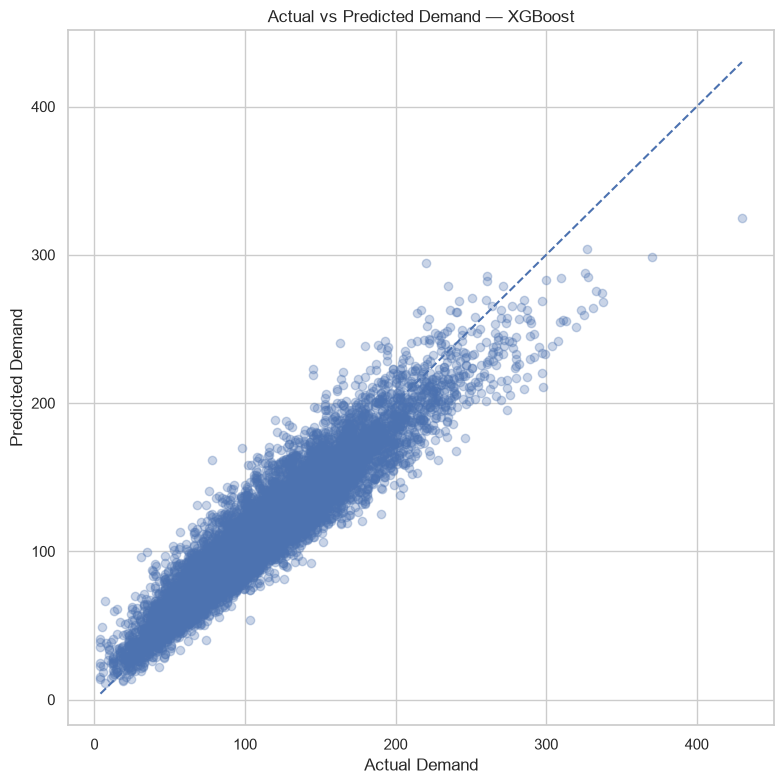

In [36]:
if best_validation_predictions is not None:

    sample_size = min(
        10000,
        len(y_validation)
    )

    indices = np.random.default_rng(42).choice(
        len(y_validation),
        size=sample_size,
        replace=False
    )

    plt.figure(figsize=(8, 8))

    plt.scatter(
        y_validation.iloc[indices],
        best_validation_predictions[indices],
        alpha=0.3
    )

    min_value = min(
        y_validation.iloc[indices].min(),
        best_validation_predictions[indices].min()
    )

    max_value = max(
        y_validation.iloc[indices].max(),
        best_validation_predictions[indices].max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.title(
        f"Actual vs Predicted Demand — {best_model_name}"
    )

    plt.xlabel("Actual Demand")
    plt.ylabel("Predicted Demand")

    plt.tight_layout()
    plt.show()

## 13. Residual Analysis

Residuals are calculated as:

Residual = Actual Demand − Predicted Demand

Residual analysis helps determine whether the model systematically
under-predicts or over-predicts demand.

In [37]:
if best_validation_predictions is not None:

    residuals = (
        y_validation.values -
        best_validation_predictions
    )

    print(
        f"Mean residual: {residuals.mean():.4f}"
    )

    print(
        f"Residual std: {residuals.std():.4f}"
    )

Mean residual: -0.2228
Residual std: 16.6952


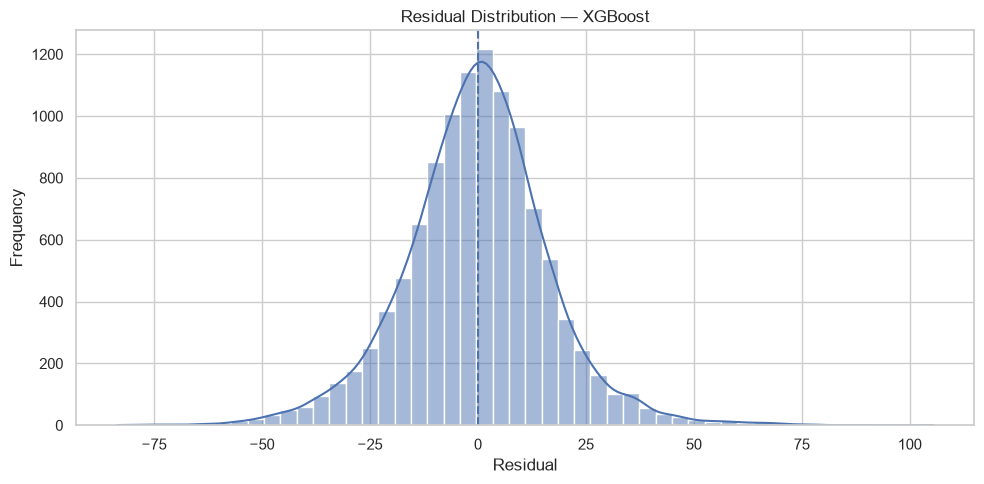

In [38]:
if best_validation_predictions is not None:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        residuals,
        bins=50,
        kde=True
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.title(
        f"Residual Distribution — {best_model_name}"
    )

    plt.xlabel("Residual")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [39]:
if best_validation_predictions is not None:

    residual_df = pd.DataFrame({
        "Actual": y_validation.values,
        "Predicted": best_validation_predictions
    })

    residual_df["Absolute_Error"] = (
        np.abs(
            residual_df["Actual"] -
            residual_df["Predicted"]
        )
    )

    residual_df["Demand_Bin"] = pd.qcut(
        residual_df["Actual"],
        q=5,
        duplicates="drop"
    )

    error_by_demand = (
        residual_df
        .groupby("Demand_Bin", observed=True)
        ["Absolute_Error"]
        .mean()
    )

    error_by_demand

## 14. Feature Importance

For tree-based models, feature importance helps identify which variables
contribute most strongly to predictions.

The importance values should be interpreted as model-specific measures rather
than causal relationships.

In [40]:
# We will inspect XGBoost feature importance first.

xgb_model = xgb_pipeline.named_steps["model"]
fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importance_values = (
    xgb_model.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
84,cat__Promotion_1,0.211727
83,cat__Promotion_0,0.166126
89,cat__Epidemic_0,0.090208
90,cat__Epidemic_1,0.089293
15,num__RollingMean_7,0.050100
39,num__Price_Change_Pct,0.043943
73,cat__Category_Groceries,0.040957
70,cat__Category_Clothing,0.029654
35,num__Discount,0.022136
72,cat__Category_Furniture,0.016921


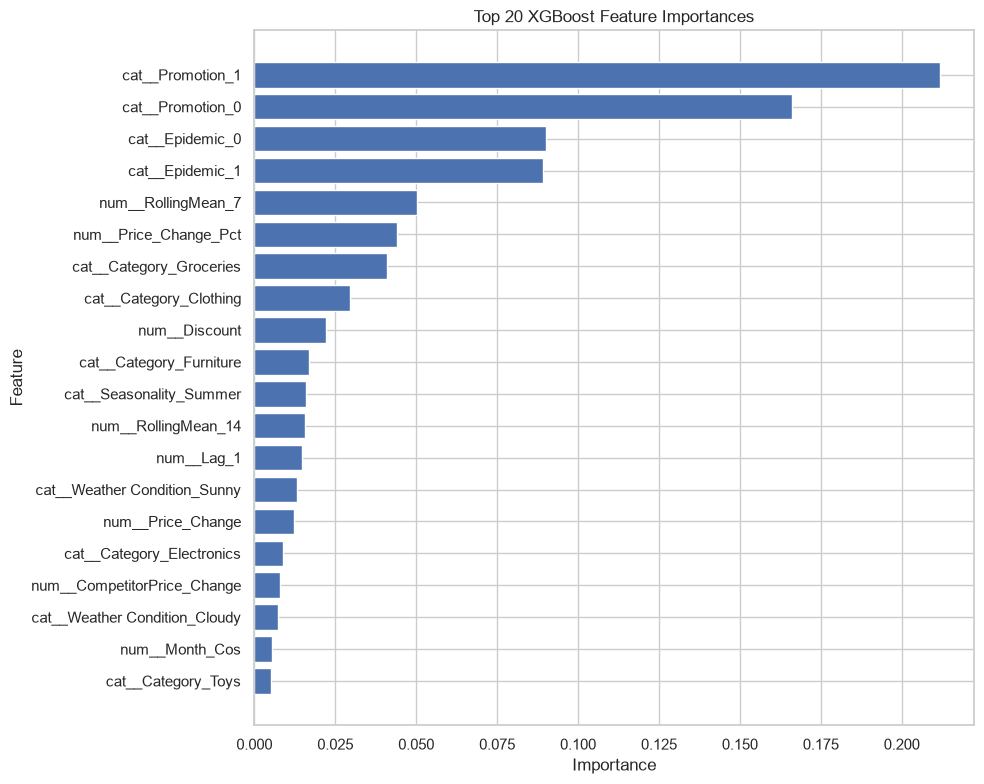

In [41]:
top_importance = (
    feature_importance
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 15. XGBoost Hyperparameter Tuning

If XGBoost is the strongest initial model, we perform a small targeted
hyperparameter search.

The validation set remains the model-selection set.

The test set is still untouched.

In [43]:
from sklearn.model_selection import ParameterGrid

In [44]:
xgb_parameter_grid = {
    "max_depth": [
        5,
        7,
        9
    ],
    "learning_rate": [
        0.03,
        0.05,
        0.08
    ],
    "n_estimators": [
        300,
        500
    ]
}

parameter_combinations = list(
    ParameterGrid(
        xgb_parameter_grid
    )
)

print(
    f"Number of parameter combinations: "
    f"{len(parameter_combinations)}"
)

Number of parameter combinations: 18


In [45]:
tuning_results = []

for params in parameter_combinations:

    model = XGBRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_validation
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    tuning_results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(
        f"Params: {params} | "
        f"MAE: {mae:.4f} | "
        f"RMSE: {rmse:.4f}"
    )

Params: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300} | MAE: 16.2058 | RMSE: 20.9830
Params: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 500} | MAE: 15.3972 | RMSE: 20.0319
Params: {'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 300} | MAE: 15.2565 | RMSE: 19.8905
Params: {'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 500} | MAE: 14.2408 | RMSE: 18.7120
Params: {'learning_rate': 0.03, 'max_depth': 9, 'n_estimators': 300} | MAE: 14.6246 | RMSE: 19.2807
Params: {'learning_rate': 0.03, 'max_depth': 9, 'n_estimators': 500} | MAE: 13.4709 | RMSE: 17.9031
Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300} | MAE: 15.4228 | RMSE: 20.0689
Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500} | MAE: 14.4622 | RMSE: 18.9818
Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300} | MAE: 14.2252 | RMSE: 18.6727
Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500} | MAE: 12.8982 | RMSE: 17.0901


In [46]:
tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    "MAE"
).reset_index(drop=True)

tuning_results_df

,learning_rate,max_depth,n_estimators,MAE,RMSE
0,0.08,7,500,11.745776,15.755652
1,0.08,9,500,11.793271,15.932176
2,0.05,9,500,12.423022,16.683587
3,0.08,9,300,12.673437,16.954167
4,0.05,7,500,12.898232,17.090114
5,0.08,7,300,13.160284,17.412077
6,0.08,5,500,13.410936,17.736874
7,0.03,9,500,13.470919,17.903146
8,0.05,9,300,13.506411,17.951374
9,0.05,7,300,14.225150,18.672741


In [47]:
best_params = (
    tuning_results_df
    .iloc[0]
    .to_dict()
)

print("Best parameters:")

for key, value in best_params.items():
    print(f"{key}: {value}")

Best parameters:
learning_rate: 0.08
max_depth: 7.0
n_estimators: 500.0
MAE: 11.745776176452637
RMSE: 15.755652003911466


## 16. Final Candidate Model

The best XGBoost configuration identified on the validation set is now
retrained using the training data.

The validation set is still retained for model comparison.

The final test evaluation will happen only once.

In [48]:
final_xgb_model = XGBRegressor(
    n_estimators=int(
        best_params["n_estimators"]
    ),
    max_depth=int(
        best_params["max_depth"]
    ),
    learning_rate=float(
        best_params["learning_rate"]
    ),
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            final_xgb_model
        )
    ]
)

final_xgb_pipeline.fit(
    X_train,
    y_train
)

print("Final XGBoost candidate trained.")

Final XGBoost candidate trained.


In [49]:
final_validation_pred = (
    final_xgb_pipeline.predict(
        X_validation
    )
)

final_validation_result = evaluate_model(
    "Tuned XGBoost",
    y_validation,
    final_validation_pred
)

pd.DataFrame([
    final_validation_result
])

,Model,MAE,RMSE,sMAPE (%),R2
0,Tuned XGBoost,11.745776,15.755652,11.506563,0.894337


## 17. Final Test Evaluation

The test dataset represents an unseen future period.

It is evaluated only after model selection and tuning have been completed.

This provides the final estimate of how the selected model performs on unseen
data.

In [50]:
final_test_pred = (
    final_xgb_pipeline.predict(
        X_test
    )
)

final_test_result = evaluate_model(
    "Tuned XGBoost",
    y_test,
    final_test_pred
)

pd.DataFrame([
    final_test_result
])

,Model,MAE,RMSE,sMAPE (%),R2
0,Tuned XGBoost,11.241747,14.949786,13.101829,0.888353


In [51]:
final_comparison = pd.DataFrame([
    {
        "Dataset": "Validation",
        **{
            key: value
            for key, value in final_validation_result.items()
            if key != "Model"
        }
    },
    {
        "Dataset": "Test",
        **{
            key: value
            for key, value in final_test_result.items()
            if key != "Model"
        }
    }
])

final_comparison

,Dataset,MAE,RMSE,sMAPE (%),R2
0,Validation,11.745776,15.755652,11.506563,0.894337
1,Test,11.241747,14.949786,13.101829,0.888353


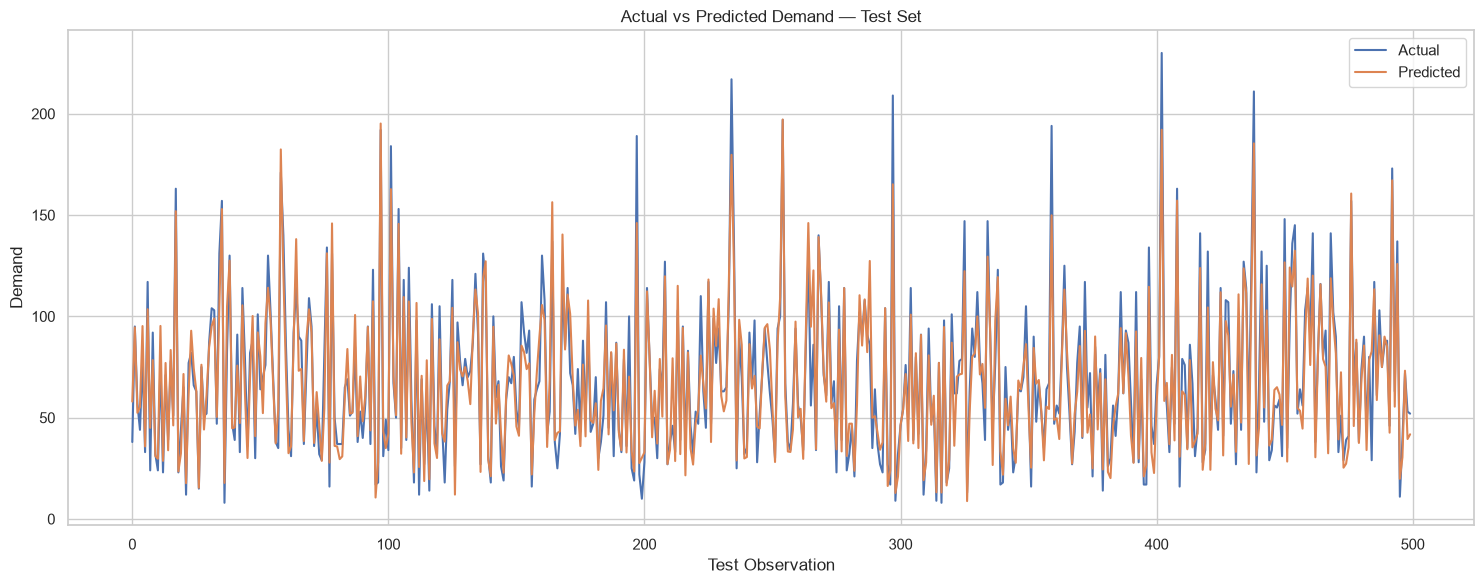

In [52]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    final_test_pred[:500],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Demand — Test Set"
)

plt.xlabel("Test Observation")
plt.ylabel("Demand")

plt.legend()

plt.tight_layout()
plt.show()

## 18. Save Final Model

The trained pipeline contains both:

- Data preprocessing
- XGBoost model

Saving the complete pipeline allows the backend application to load the model
and make predictions using the same preprocessing steps.

In [53]:
os.makedirs(
    "../models",
    exist_ok=True
)

MODEL_PATH = (
    "../models/best_demand_model.pkl"
)

with open(
    MODEL_PATH,
    "wb"
) as file:
    
    pickle.dump(
        final_xgb_pipeline,
        file
    )

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: ../models/best_demand_model.pkl


In [54]:
metadata = {
    "target": TARGET,
    "model": "XGBoost",
    "best_parameters": {
        "n_estimators": int(
            best_params["n_estimators"]
        ),
        "max_depth": int(
            best_params["max_depth"]
        ),
        "learning_rate": float(
            best_params["learning_rate"]
        )
    },
    "number_of_features": len(feature_columns),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "train_rows": len(train_df),
    "validation_rows": len(validation_df),
    "test_rows": len(test_df),
    "train_start": str(
        train_df["Date"].min().date()
    ),
    "train_end": str(
        train_df["Date"].max().date()
    ),
    "validation_start": str(
        validation_df["Date"].min().date()
    ),
    "validation_end": str(
        validation_df["Date"].max().date()
    ),
    "test_start": str(
        test_df["Date"].min().date()
    ),
    "test_end": str(
        test_df["Date"].max().date()
    ),
    "validation_metrics": {
        "MAE": float(
            final_validation_result["MAE"]
        ),
        "RMSE": float(
            final_validation_result["RMSE"]
        ),
        "sMAPE": float(
            final_validation_result["sMAPE (%)"]
        ),
        "R2": float(
            final_validation_result["R2"]
        )
    },
    "test_metrics": {
        "MAE": float(
            final_test_result["MAE"]
        ),
        "RMSE": float(
            final_test_result["RMSE"]
        ),
        "sMAPE": float(
            final_test_result["sMAPE (%)"]
        ),
        "R2": float(
            final_test_result["R2"]
        )
    }
}

METADATA_PATH = (
    "../models/model_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:
    
    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    f"Metadata saved to: {METADATA_PATH}"
)

Metadata saved to: ../models/model_metadata.json


In [55]:
os.makedirs(
    "../reports/model_results",
    exist_ok=True
)

validation_results.to_csv(
    "../reports/model_results/"
    "validation_model_comparison.csv",
    index=False
)

tuning_results_df.to_csv(
    "../reports/model_results/"
    "xgboost_tuning_results.csv",
    index=False
)

final_comparison.to_csv(
    "../reports/model_results/"
    "final_test_results.csv",
    index=False
)

print("Model evaluation results saved.")

Model evaluation results saved.


# 19. Final Model Summary

The demand forecasting pipeline has been trained and evaluated.

### Models evaluated

- Mean Demand Baseline
- Lag-1 Baseline
- Ridge Regression
- Random Forest
- XGBoost

### Model selection

The validation dataset was used to compare the candidate models.

Hyperparameter tuning was then applied to the XGBoost model.

### Final evaluation

The final selected model was evaluated once on the unseen test period.

### Saved artifacts

The trained model pipeline is saved as:

`models/best_demand_model.pkl`

Model metadata is saved as:

`models/model_metadata.json`

Evaluation results are saved under:

`reports/model_results/`

### Next Stage

The next stage is to integrate the trained forecasting model into the
application backend.

Before that, the model's forecasting output will be connected to an inventory
optimization layer that can calculate:

- Expected demand
- Safety stock
- Reorder point
- Recommended order quantity
- Inventory risk

The trained forecasting model will therefore become one component of the
larger retail decision-support platform.